In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from utils.db_connection import run_query


In [4]:
df = run_query("SELECT * FROM air_quality;")

print(df.shape)
print(df.head())
df.info()
df.describe()


c:\Users\deepb\Desktop\Pollution data analytics\PYTHON\utils\db_connection.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(3240, 12)
   id country  state     city                     station last_update  \
0   1   India  Assam  Nalbari  Bata Chowk, Nalbari - PCBA        None   
1   2   India  Assam  Nalbari  Bata Chowk, Nalbari - PCBA        None   
2   3   India  Assam  Silchar     Tarapur, Silchar - PCBA        None   
3   4   India  Assam  Silchar     Tarapur, Silchar - PCBA        None   
4   5   India  Assam  Silchar     Tarapur, Silchar - PCBA        None   

    latitude  longitude pollutant_id  pollutant_min  pollutant_max  \
0  26.446912  91.439057          NH3            5.0            7.0   
1  26.446912  91.439057          SO2            4.0            8.0   
2  24.828270  92.795250         PM10           35.0           64.0   
3  24.828270  92.795250           CO           34.0           46.0   
4  24.828270  92.795250        OZONE            1.0            6.0   

   pollutant_avg  
0            6.0  
1            8.0  
2           45.0  
3           40.0  
4            3.0  
<class 'pandas.

,id,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,1620.500000,22.694046,78.526411,27.151543,81.387963,50.684877
std,935.451763,5.577168,4.707390,34.633576,100.874242,63.442903
min,1.000000,8.514909,70.909168,1.000000,1.000000,1.000000
25%,810.750000,19.065931,75.578914,5.750000,16.000000,11.000000
50%,1620.500000,23.500160,77.321700,14.000000,43.000000,27.000000
75%,2430.250000,27.213494,80.263188,33.250000,104.000000,61.000000
max,3240.000000,34.066206,94.636574,316.000000,500.000000,428.000000


In [5]:
# dATA Cleaning and prep 
df = df.dropna(subset=['pollutant_avg'])
df = df[df['pollutant_avg'] >= 0]  # remove invalid negatives


In [7]:
# Key Performance Indicators (KPIs)

# 1 pollutuion avg by city 
city_avg = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False)
city_avg.head(10)


city
Noida             148.461538
Nandesari         138.333333
Delhi             122.031746
Ghaziabad         116.000000
Greater Noida     114.428571
Sri Ganganagar    105.428571
Dharuhera         104.571429
Bhiwadi           100.357143
Meerut             99.437500
Gurugram           98.333333
Name: pollutant_avg, dtype: float64

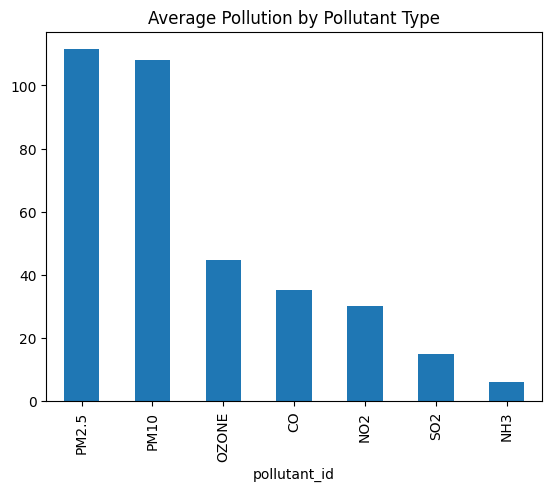

In [8]:
# 2 POLLUTION by Pollutant type
pollutant_type = df.groupby('pollutant_id')['pollutant_avg'].mean().sort_values(ascending=False)
pollutant_type.plot(kind='bar', title='Average Pollution by Pollutant Type')
plt.show()


In [10]:
# 3 Most pollutated cities 
top_cities = df.groupby('city')['pollutant_avg'].mean().nlargest(10).reset_index()

# set y-axis range slightly below min and slightly above max
min_val = top_cities['pollutant_avg'].min()
max_val = top_cities['pollutant_avg'].max()

px.bar(
    top_cities, 
    x='city', 
    y='pollutant_avg', 
    title='Top 10 Polluted Cities',
    range_y=[min_val * 0.95, max_val * 1.05]  # zoom in on data range
).show()

In [11]:
# GEO VISUALIZATION 
geo = df.groupby(['city','latitude','longitude'])['pollutant_avg'].mean().reset_index()
fig = px.scatter_geo(
    geo, lat='latitude', lon='longitude', color='pollutant_avg',
    hover_name='city', title='Average Pollution by Location',
    color_continuous_scale='Reds'
)
fig.show()


In [13]:
# Threshold & Exceedance Analysis
unsafe = df[df['pollutant_avg'] > 100]
print(f"Unsafe Records: {len(unsafe)} / {len(df)} ({len(unsafe)/len(df)*100:.2f}%)")

city_exceed = unsafe.groupby('city')['pollutant_avg'].count().sort_values(ascending=False)
city_exceed.head(10)

px.bar(city_exceed.head(10), x=city_exceed.head(10).index, y=city_exceed.head(10).values,
       title="Top 10 Cities by Pollution Exceedance (>100 µg/m³)")


Unsafe Records: 486 / 3240 (15.00%)


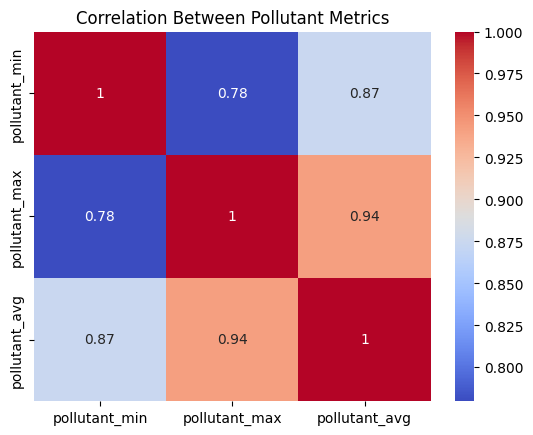

In [14]:
# Correlation Heatmap 
corr = df[['pollutant_min','pollutant_max','pollutant_avg']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Pollutant Metrics')
plt.show()


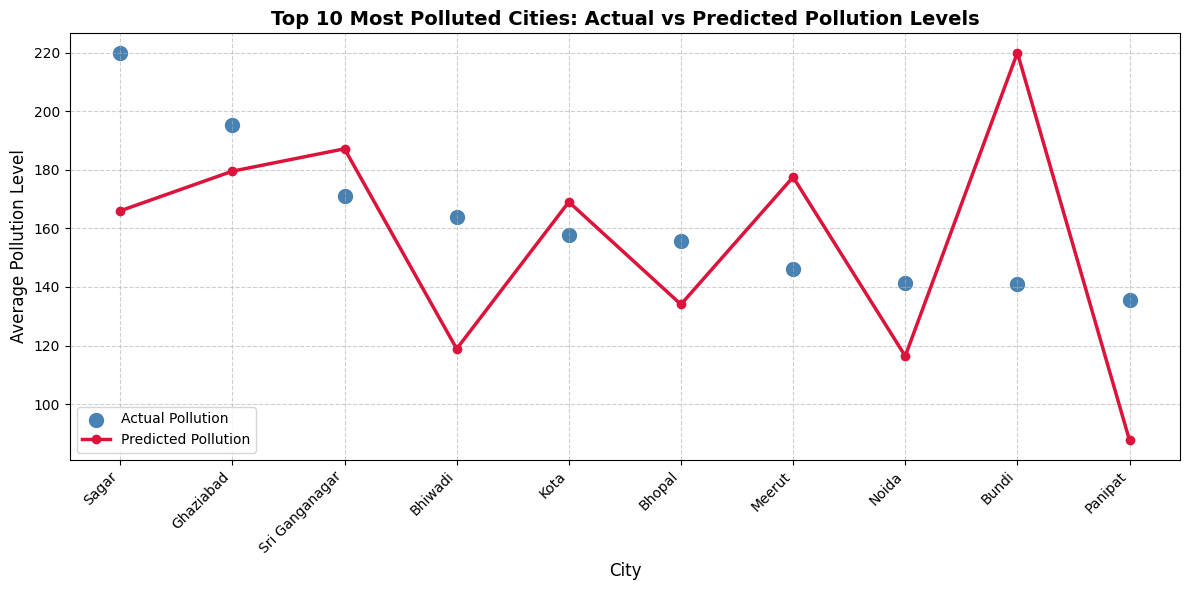

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine predictions with city info
plot_df = X_test.copy()
plot_df['city'] = df.loc[X_test.index, 'city']
plot_df['Actual Pollution'] = y_test.values
plot_df['Predicted Pollution'] = y_pred

# Average pollution per city
city_avg = plot_df.groupby('city')[['Actual Pollution', 'Predicted Pollution']].mean().reset_index()

# Pick top 10 most polluted cities (by actual pollution)
top10 = city_avg.sort_values(by='Actual Pollution', ascending=False).head(10)

plt.figure(figsize=(12,6))

# Scatter for Actual
plt.scatter(top10['city'], top10['Actual Pollution'], 
            color='steelblue', s=100, label='Actual Pollution')

# Line for Predicted
plt.plot(top10['city'], top10['Predicted Pollution'], 
         color='crimson', linewidth=2.5, marker='o', label='Predicted Pollution')

plt.xticks(rotation=45, ha='right')
plt.xlabel("City", fontsize=12)
plt.ylabel("Average Pollution Level", fontsize=12)
plt.title("Top 10 Most Polluted Cities: Actual vs Predicted Pollution Levels", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Model Performance:
-------------------
R² Score: 0.938
Mean Absolute Error: 7.34


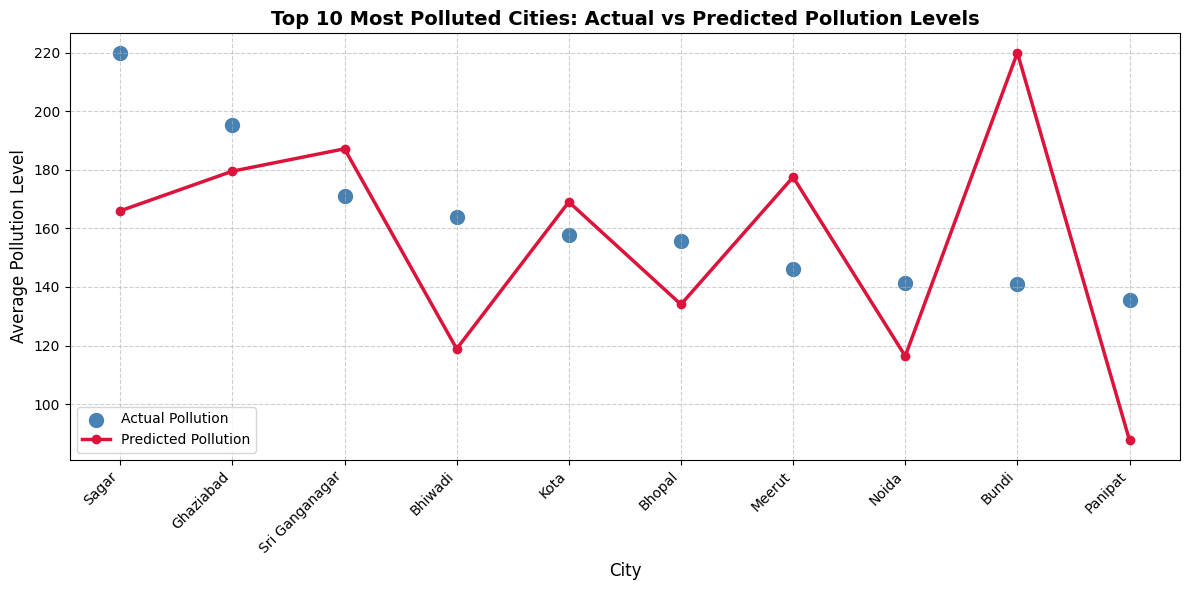

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score


X = df[['pollutant_min', 'pollutant_max']]
y = df['pollutant_avg']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================
# STEP 3: Polynomial Regression (degree 2 for better fit)
# ==========================
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# ==========================
# STEP 4: Train the Model
# ==========================
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ==========================
# STEP 5: Predict and Evaluate
# ==========================
y_pred = model.predict(X_test_scaled)

print("Model Performance:")
print("-------------------")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 2))

# ==========================
# STEP 6: Combine results with city info
# ==========================
plot_df = X_test.copy()
plot_df['city'] = df.loc[X_test.index, 'city']
plot_df['Actual Pollution'] = y_test.values
plot_df['Predicted Pollution'] = y_pred

# Group by city
city_avg = plot_df.groupby('city')[['Actual Pollution', 'Predicted Pollution']].mean().reset_index()

# Top 10 most polluted cities
top10 = city_avg.sort_values(by='Actual Pollution', ascending=False).head(10)

# ==========================
# STEP 7: Visualize Results
# ==========================
plt.figure(figsize=(12,6))

# Scatter for Actual Pollution
plt.scatter(top10['city'], top10['Actual Pollution'], 
            color='steelblue', s=100, label='Actual Pollution')

# Line for Predicted Pollution
plt.plot(top10['city'], top10['Predicted Pollution'], 
         color='crimson', linewidth=2.5, marker='o', label='Predicted Pollution')

plt.xticks(rotation=45, ha='right')
plt.xlabel("City", fontsize=12)
plt.ylabel("Average Pollution Level", fontsize=12)
plt.title("Top 10 Most Polluted Cities: Actual vs Predicted Pollution Levels", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [23]:
summary = {
    "Total Records": len(df),
    "Unique Cities": df['city'].nunique(),
    "Unique Stations": df['station'].nunique(),
    "Average Pollution": df['pollutant_avg'].mean().round(2),
    "Max Pollution": df['pollutant_max'].max().round(2),
    "Unsafe Percentage": round((len(unsafe)/len(df))*100, 2)
}
pd.DataFrame([summary])


,Total Records,Unique Cities,Unique Stations,Average Pollution,Max Pollution,Unsafe Percentage
0,3240,270,509,50.68,500.0,15.0
